  checking_account  duration credit_history purpose  credit_amount savings  \
0              A11         6            A34     A43           1169     A65   
1              A12        48            A32     A43           5951     A61   
2              A14        12            A34     A46           2096     A61   
3              A11        42            A32     A42           7882     A61   
4              A11        24            A33     A40           4870     A61   

  employment  installment_rate personal_status other_debtors  ...  property  \
0        A75                 4             A93          A101  ...      A121   
1        A73                 2             A92          A101  ...      A121   
2        A74                 2             A93          A101  ...      A121   
3        A74                 2             A93          A103  ...      A122   
4        A73                 3             A93          A101  ...      A124   

  age  other_installment_plans housing existing_credits 

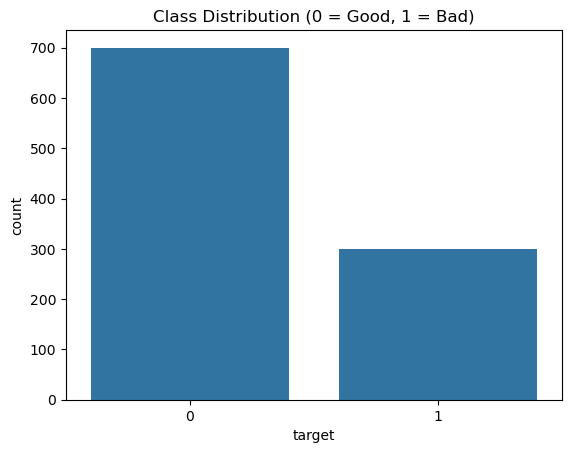

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-validation F1 scores: [0.62385321 0.56140351 0.56666667 0.71186441 0.5862069 ]
Average CV F1 score: 0.6099989379558312

--- MODEL EVALUATION ---
Accuracy: 0.72
Precision: 0.5172413793103449
Recall: 0.7627118644067796
F1 Score: 0.6164383561643836


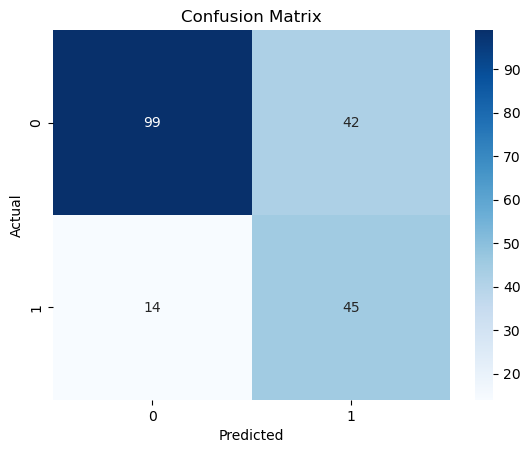

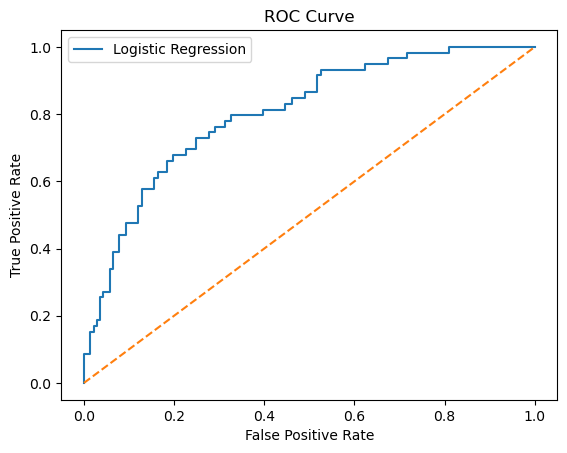

ROC-AUC Score: 0.8044236086068036


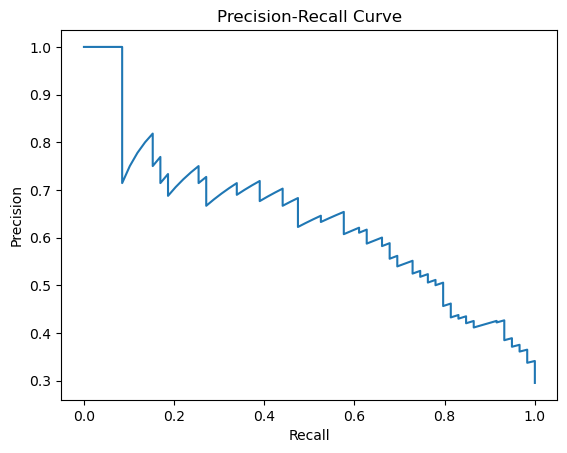


--- CUSTOM THRESHOLD (0.3) ---
Accuracy: 0.505
Recall: 0.9661016949152542


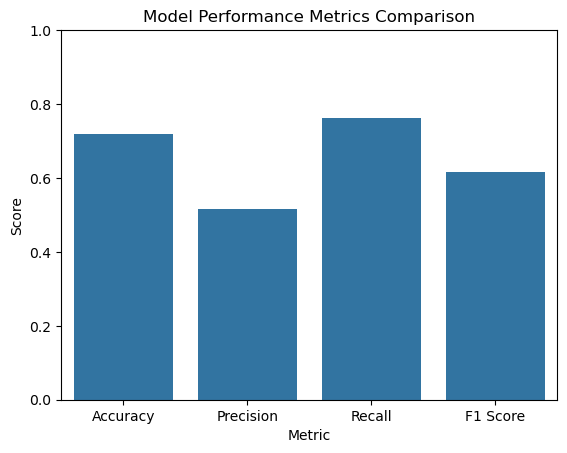

Default Threshold Cost: 112
Custom Threshold Cost: 107


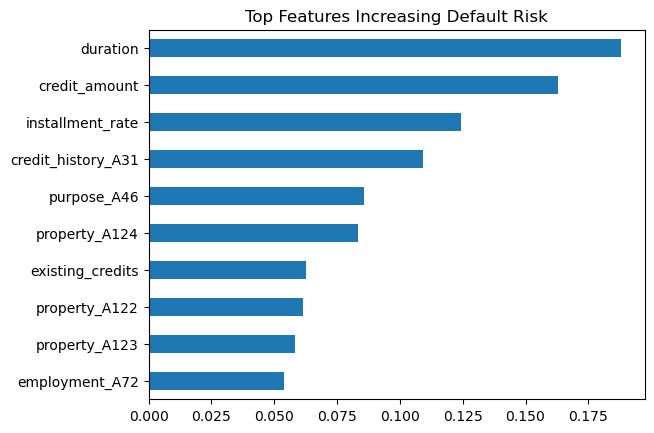

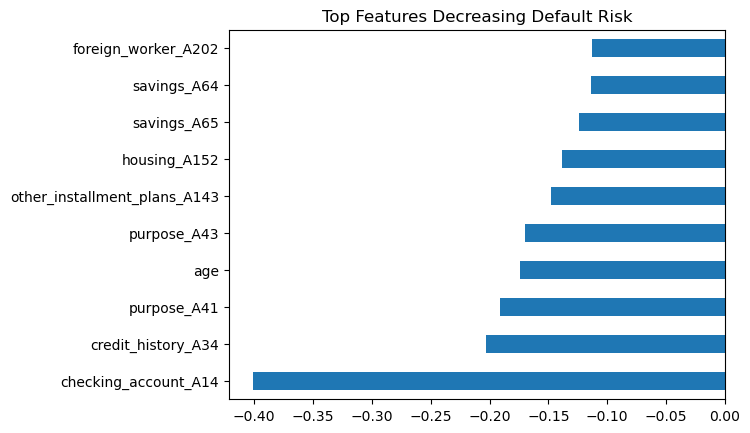

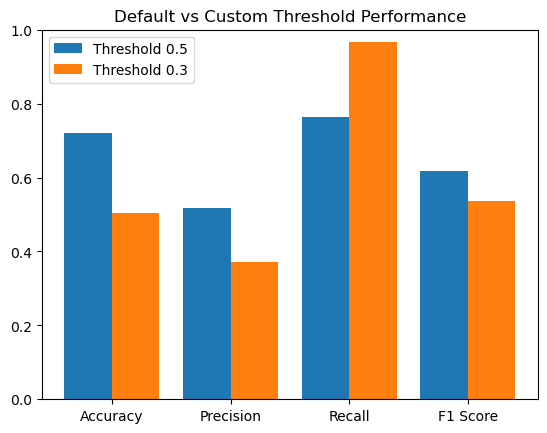

In [ ]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Hyperparameter tuning
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import precision_recall_curve

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

# 2. LOAD DATASET

# Column names based on dataset description
column_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings", "employment", "installment_rate",
    "personal_status", "other_debtors", "residence_since",
    "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "dependents", "telephone",
    "foreign_worker", "target"
]

df = pd.read_csv("german.data", sep="\s+", header=None, names=column_names)

# 3. DATA UNDERSTANDING

# print("First 5 rows:")
print(df.head())

# print("\nDataset Info:")
print(df.info())

# print("\nClass Distribution:")
print(df['target'].value_counts())

# 4. TARGET TRANSFORMATION

# Convert target:
# 1 (Good) -> 0
# 2 (Bad)  -> 1 (default)
df['target'] = df['target'].map({1: 0, 2: 1})

# 5. EXPLORATORY DATA ANALYSIS

sns.countplot(x='target', data=df)
plt.title("Class Distribution (0 = Good, 1 = Bad)")
plt.show()

# 6. PREPROCESSING

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Convert categorical variables to numerical (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 7. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. FEATURE SCALING

# Important for Logistic Regression
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. HYPERPARAMETER TUNING 

param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 5],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

# Best model
model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# 9.1 CROSS-VALIDATION 

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Average CV F1 score:", np.mean(cv_scores))

# 10. PREDICTIONS

# Predicted classes
y_pred = model.predict(X_test)

# Predicted probabilities (for ROC, threshold tuning)
y_prob = model.predict_proba(X_test)[:, 1]

# 11. EVALUATION METRICS

print("\n--- MODEL EVALUATION ---")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision
print("Precision:", precision_score(y_test, y_pred))

# Recall
print("Recall:", recall_score(y_test, y_pred))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred))

# 12. CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 13. ROC CURVE + AUC

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# 13.1 PRECISION-RECALL CURVE 

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# 14. THRESHOLD TUNING (ADVANCED)

# Change decision threshold from 0.5 to 0.3
y_pred_custom = (y_prob > 0.3).astype(int)

print("\n--- CUSTOM THRESHOLD (0.3) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))

# 15. FINAL METRICS COMPARISON GRAPH

# Store metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

# Convert to DataFrame
metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])

# Plot
plt.figure()
sns.barplot(x="Metric", y="Score", data=metrics_df)
plt.title("Model Performance Metrics Comparison")
plt.ylim(0, 1)
plt.show()

# 16. COST-SENSITIVE EVALUATION 

def calculate_cost(y_true, y_pred):
    cost = 0
    for actual, pred in zip(y_true, y_pred):
        if actual == 1 and pred == 0:  # Bad predicted as Good
            cost += 5
        elif actual == 0 and pred == 1:  # Good predicted as Bad
            cost += 1
    return cost

default_cost = calculate_cost(y_test, y_pred)
custom_cost = calculate_cost(y_test, y_pred_custom)

print("Default Threshold Cost:", default_cost)
print("Custom Threshold Cost:", custom_cost)

# 17. FEATURE IMPORTANCE 

# Get feature importance (coefficients)
importance = pd.Series(model.coef_[0], index=X.columns)

# Plot top features
importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Features Increasing Default Risk")
plt.show()

importance.sort_values().head(10).plot(kind='barh')
plt.title("Top Features Decreasing Default Risk")
plt.show()

# 18. THRESHOLD COMPARISON GRAPH

metrics_default = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

metrics_custom = [
    accuracy_score(y_test, y_pred_custom),
    precision_score(y_test, y_pred_custom),
    recall_score(y_test, y_pred_custom),
    f1_score(y_test, y_pred_custom)
]

labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, metrics_default, width=0.4, label="Threshold 0.5")
plt.bar(x + 0.2, metrics_custom, width=0.4, label="Threshold 0.3")

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Default vs Custom Threshold Performance")
plt.legend()
plt.show()